In [ ]:
# Load libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
# load data
from google.colab import files
uploaded=files.upload()
df=pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()

Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn (1).csv


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [ ]:
df.index

RangeIndex(start=0, stop=7043, step=1)

**Data Pre-Processing**

1.Data Cleaning

In [ ]:
# Handle Missing values
df.isnull().sum().sort_values(ascending=False)

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
# Handle duplicates
df.duplicated().sum()

np.int64(0)

In [ ]:
# check data types
df.dtypes


,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


EDA(Exploratory Data Analysis)

<Axes: xlabel='Churn', ylabel='count'>

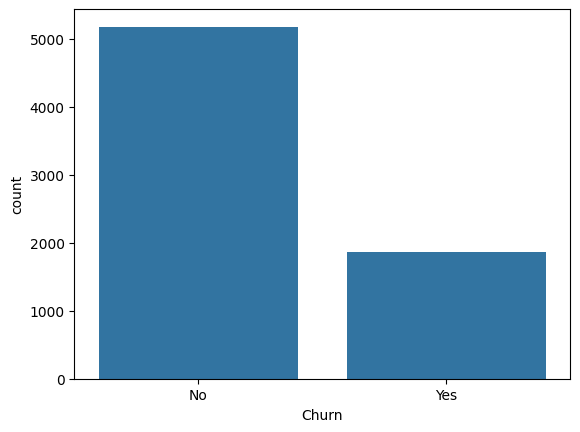

In [ ]:
# Check churn behavior
sns.countplot(x='Churn',data=df)

<Axes: xlabel='Contract', ylabel='count'>

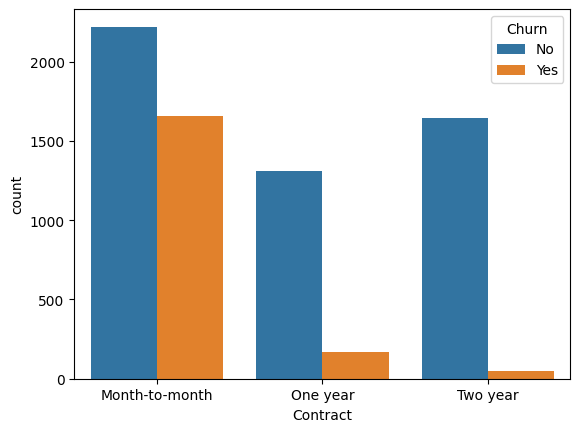

In [ ]:
# Contract vs churn
sns.countplot(x='Contract',hue='Churn',data=df)

<Axes: xlabel='tenure', ylabel='count'>

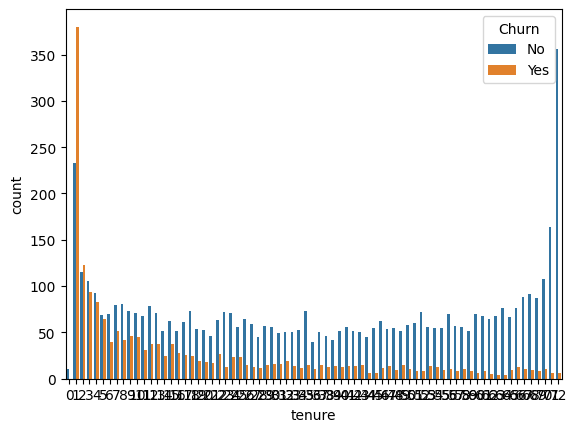

In [ ]:
# tenure vs churn
sns.countplot(x='tenure',hue='Churn',data=df)

# Feature Engineering

In [ ]:
# Remove un neccessary columns
df.drop('customerID',axis=1,inplace=True)

In [ ]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

Encoding

In [ ]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['gender']=le.fit_transform(df['gender'])
df['Partner']=le.fit_transform(df['Partner'])
df['Dependents']=le.fit_transform(df['Dependents'])
df['PhoneService']=le.fit_transform(df['PhoneService'])
df['MultipleLines']=le.fit_transform(df['MultipleLines'])
df['InternetService']=le.fit_transform(df['InternetService'])
df['DeviceProtection']=le.fit_transform(df['DeviceProtection'])
df['OnlineBackup']=le.fit_transform(df['OnlineBackup'])
df['TechSupport']=le.fit_transform(df['TechSupport'])
df['PaperlessBilling']=le.fit_transform(df['PaperlessBilling'])
df['OnlineSecurity']=le.fit_transform(df['OnlineSecurity'])
df['StreamingTV']=le.fit_transform(df['StreamingTV'])
df['StreamingMovies']=le.fit_transform(df['StreamingMovies'])
df['Contract']=le.fit_transform(df['Contract'])
df['PaymentMethod']=le.fit_transform(df['PaymentMethod'])
df['Churn']=le.fit_transform(df['Churn'])
df['TotalCharges']=le.fit_transform(df['TotalCharges'])


In [ ]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,2505,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1466,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,157,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1400,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,925,1


Feature and target Split

In [ ]:
X=df.drop('Churn',axis=1)
y=df['Churn']

Train Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

Feature Selection

In [ ]:
y_test.shape

(1409,)

In [ ]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()

X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

***Work on model(LOGISTIC REGRESSION)***

Train the model

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

Predict the model

In [ ]:
y_pred=model.predict(X_test)
y_pred

array([1, 0, 0, ..., 0, 0, 0])

In [ ]:
pred_df=pd.DataFrame({
    'Acual':y_test,
    'Predicted':y_pred
})

In [ ]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,recall_score,precision_score,f1_score

Evaluate the mode

In [ ]:
print(f'Accuracy Score:{accuracy_score(y_test,y_pred)}')
print(f'Confusion Matrix:{confusion_matrix(y_test,y_pred)}')
print(f'Recall Score:{recall_score(y_test,y_pred)}')
print(f'Precision Score:{precision_score(y_test,y_pred)}')
print(f'F1 Score:{f1_score(y_test,y_pred)}')

Accuracy Score:0.8019872249822569
Confusion Matrix:[[928  97]
 [182 202]]
Recall Score:0.5260416666666666
Precision Score:0.6755852842809364
F1 Score:0.5915080527086384


Actual vs predicted

In [ ]:
df_test.shape

(1409, 2)

In [ ]:
df_test=pd.DataFrame({
    'Actual':y_test,
    'Predicted':y_pred
})
df_test.head()

,Actual,Predicted
6936,1,1
2657,0,0
1273,0,0
3793,0,0
6211,1,1


Heat map

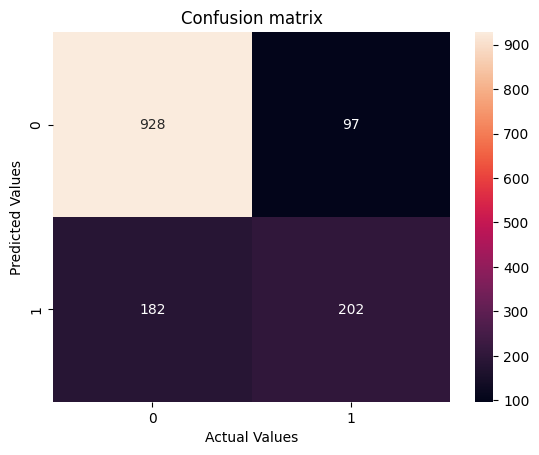

In [ ]:
cm=confusion_matrix(y_test,y_pred)
sns.heatmap(cm,annot=True,fmt='d')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Confusion matrix')
plt.show()

**Business Insights**

1.Customers with month-to-month contracts have a higher churn rate compared to long-term contracts.

2.Customers with low tenure are more likely to churn, while long-term customers tend to stay.

3. According to the confusion matrix, the model correctly identifies a large number of loyal customers and also detects many churn customers.

4. However, the model still misses some churn cases, indicating that there is room for improvement.

5. These insights suggest that customer retention strategies should focus on new customers and short-term contracts

# **Conclusion**:

"This project successfully analyzes customer churn in a Telco company using machine learning techniques. The results show that contract type and tenure are key factors affecting customer churn. The model is able to predict churn with good accuracy, helping the company identify at-risk customers. By taking proactive actions based on these insights, the company can reduce customer loss and improve retention."